# K-Means Clustering: Student Performance Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
df = pd.read_csv('student_performance_kmeans.csv')
df.head()

,StudentID,StudyHours,Attendance,PreviousMarks,InternalAssessment,ExtracurricularScore
0,1,7,73,45,38,54
1,2,4,86,89,41,22
2,3,13,84,31,30,67
3,4,11,93,30,87,29
4,5,8,89,77,30,81


In [3]:
# Select features
X = df[['StudyHours', 'Attendance', 'PreviousMarks', 'InternalAssessment', 'ExtracurricularScore']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\Users\NITHISHA REDDY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\NITHISHA REDDY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\NITHISHA REDDY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\NITHISHA REDDY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

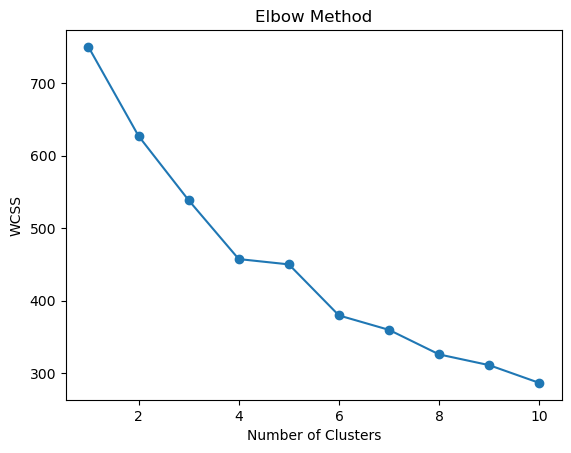

In [4]:
# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [5]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

c:\Users\NITHISHA REDDY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,StudentID,StudyHours,Attendance,PreviousMarks,InternalAssessment,ExtracurricularScore,Cluster
0,1,7,73,45,38,54,0
1,2,4,86,89,41,22,2
2,3,13,84,31,30,67,0
3,4,11,93,30,87,29,0
4,5,8,89,77,30,81,0


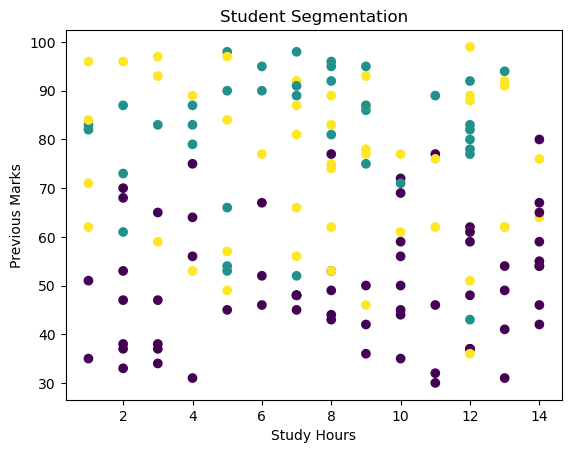

In [6]:
# Visualization (2D)
plt.scatter(df['StudyHours'], df['PreviousMarks'], c=df['Cluster'])
plt.xlabel('Study Hours')
plt.ylabel('Previous Marks')
plt.title('Student Segmentation')
plt.show()

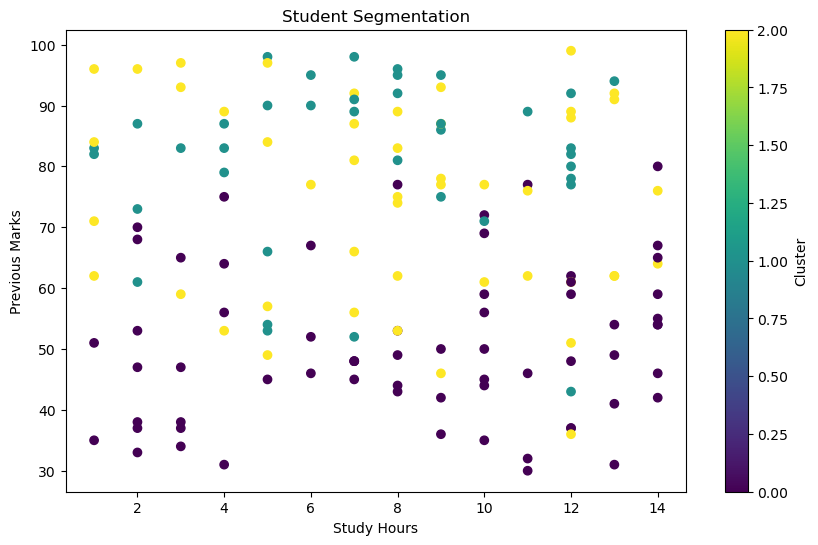

In [13]:
# Final visualization
plt.figure(figsize=(10, 6))
plt.scatter(df['StudyHours'], df['PreviousMarks'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Study Hours')
plt.ylabel('Previous Marks')
plt.title('Student Segmentation')
plt.colorbar(label='Cluster')
plt.show()


In [7]:
# Find cluster centers (original scale)
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(centers, columns=X.columns)
centers_df['Cluster'] = range(0, 3)

centers_df

,StudyHours,Attendance,PreviousMarks,InternalAssessment,ExtracurricularScore,Cluster
0,8.292308,75.676923,50.584615,60.384615,66.661538,0
1,7.210526,62.894737,81.315789,81.973684,57.078947,1
2,7.893617,81.574468,74.680851,52.808511,30.851064,2


In [8]:
# Compute performance score
centers_df['PerformanceScore'] = (
    centers_df['StudyHours'] +
    centers_df['Attendance'] +
    centers_df['PreviousMarks'] +
    centers_df['InternalAssessment']
)

# Sort clusters
centers_df = centers_df.sort_values(by='PerformanceScore')

# Assign labels
labels = ['At-Risk', 'Average', 'Topper']
centers_df['Label'] = labels

centers_df[['Cluster', 'Label']]

,Cluster,Label
0,0,At-Risk
2,2,Average
1,1,Topper


In [9]:
# Map labels to dataset
cluster_label_map = dict(zip(centers_df['Cluster'], centers_df['Label']))

df['Category'] = df['Cluster'].map(cluster_label_map)

df.head()

,StudentID,StudyHours,Attendance,PreviousMarks,InternalAssessment,ExtracurricularScore,Cluster,Category
0,1,7,73,45,38,54,0,At-Risk
1,2,4,86,89,41,22,2,Average
2,3,13,84,31,30,67,0,At-Risk
3,4,11,93,30,87,29,0,At-Risk
4,5,8,89,77,30,81,0,At-Risk


In [14]:
# metrics
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhouette Score: {silhouette_avg:.2f}')


Silhouette Score: 0.15


In [15]:
# inertia
print(f'Inertia: {kmeans.inertia_:.2f}')


Inertia: 538.44
